## Download Dataset from Roboflow Universe

In [1]:
import os
from roboflow import Roboflow
rf = Roboflow(api_key=os.environ.get("ROBOFLOW_API_KEY"))
project = rf.workspace("fyp-vfrgn").project("7-classes-vehicle")
version = project.version(1)
dataset = version.download("yolo26")

loading Roboflow workspace...
loading Roboflow project...


### Verify dataset structure

In [2]:
# Cell 3: Verify dataset structure
import os
from pathlib import Path

dataset_dir = Path("7-classes-vehicle-1")

# Check data.yaml exists
yaml_path = dataset_dir / "data.yaml"
if yaml_path.exists():
    print(f"Found: {yaml_path}")
    with open(yaml_path) as f:
        print(f.read())
else:
    print("data.yaml not found! Check directory:")
    for p in sorted(dataset_dir.rglob("*.yaml")):
        print(f"  {p}")

# Check splits
for split in ["train", "valid", "test"]:
    img_dir = dataset_dir / split / "images"
    lbl_dir = dataset_dir / split / "labels"
    if img_dir.exists():
        n_imgs = len(list(img_dir.glob("*.*")))
        n_lbls = len(list(lbl_dir.glob("*.txt")))
        print(f"{split}: {n_imgs} images, {n_lbls} labels")

Found: 7-classes-vehicle-1\data.yaml
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 7
names: ['Bus', 'Motorcycle', 'Pickup', 'Sedan', 'Suv', 'Truck', 'Van']

roboflow:
  workspace: fyp-vfrgn
  project: 7-classes-vehicle
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/fyp-vfrgn/7-classes-vehicle/dataset/1
train: 5819 images, 5819 labels
valid: 727 images, 727 labels
test: 728 images, 728 labels


### Verify GPU

In [3]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA Version: {torch.version.cuda}")
print(f"Device Count: {torch.cuda.device_count()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

CUDA available: True
CUDA Version: 12.1
Device Count: 1
GPU: NVIDIA GeForce RTX 4060
VRAM: 8.6 GB


In [4]:
from ultralytics import YOLO
model = YOLO("yolo26m.pt")
results = model.train(
   data="7-classes-vehicle-1/data.yaml",
   # --- Core ---
   epochs=150,
   batch=8,
   imgsz=640,
   patience=20,
   # --- Optimizer ---
   optimizer="AdamW",
   lr0=1e-3,
   lrf=0.01,
   weight_decay=5e-4,
   warmup_epochs=3.0,
   # --- Loss weights ---
   cls=1.5,
   box=7.5,
   # --- Augmentation ---
   hsv_h=0.015,
   hsv_s=0.7,
   hsv_v=0.4,
   degrees=0.0,
   translate=0.1,
   scale=0.5,
   fliplr=0.5,
   mosaic=1.0,
   mixup=0.1,
   copy_paste=0.1,
   close_mosaic=10,
   # --- Logging ---
   project="vehicle_detection",
   name="yolo26m",
   plots=True,
   save=True,
   val=True,
)


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2+cu121
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


New https://pypi.org/project/ultralytics/8.4.37 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.34  Python-3.11.9 torch-2.2.2+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=7-classes-vehicle-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yo

2026-04-10 20:41:29,394	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-04-10 20:41:33,701	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Overriding model.yaml nc=80 with nc=7

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  1    111872  ultralytics.nn.modules.block.C3k2            [128, 256, 1, True, 0.25]     
  3                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  4                  -1  1    444928  ultralytics.nn.modules.block.C3k2            [256, 512, 1, True, 0.25]     
  5                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  6                  -1  1   1380352  ultralytics.nn.modules.block.C3k2            [512, 512, 1, True]           
  7                  -1  1   2360320  ultralytics

### Hyperparameter Tuning (Ray Tune)

In [ ]:
from ray import tune
from ultralytics import YOLO
from pathlib import Path

model = YOLO("yolo26s.pt")

data_path = str(Path("imbalanced-2/data.yaml").resolve())

result_grid = model.tune(
    data=data_path,

    epochs=50,
    imgsz=640,
    batch=16,
    optimizer="AdamW",
    patience=10,
    close_mosaic=10,

    use_ray=True,
    iterations=30,
    gpu_per_trial=1,
    grace_period=10,

    space={
        "lr0": tune.uniform(5e-4, 5e-3),
        "lrf": tune.uniform(0.005, 0.1),
        "warmup_epochs": tune.uniform(1.0, 5.0),
        "weight_decay": tune.uniform(1e-4, 1e-3),
        # Loss weights (most impactful for class confusion)
        "cls": tune.uniform(0.5, 4.0),
        "box": tune.uniform(5.0, 15.0),
        # Augmentation (helps minority classes)
        "mosaic": tune.uniform(0.5, 1.0),
        "copy_paste": tune.uniform(0.0, 0.5),
        "mixup": tune.uniform(0.0, 0.3),
        "scale": tune.uniform(0.2, 0.9),
        "hsv_s": tune.uniform(0.3, 0.9),
        "hsv_v": tune.uniform(0.2, 0.6),
        "fliplr": tune.uniform(0.3, 0.7),
    },

    project="vehicle_detection",
    name="ray_tune_yolo26s",
)

### Check best hyperparameters

In [7]:
from ray.tune import ExperimentAnalysis
from pathlib import Path

experiment_path = str(Path("../runs/detect/vehicle_detection/ray_tune_yolo26s6").resolve())
analysis = ExperimentAnalysis(experiment_path)

# Get the best trial config by mAP@50
best_config = analysis.get_best_config(metric="metrics/mAP50(B)", mode="max")

print("=" * 60)
print("BEST HYPERPARAMETERS (by mAP@50)")
print("=" * 60)
for k, v in best_config.items():
    print(f"  {k}: {v}")

BEST HYPERPARAMETERS (by mAP@50)
  lr0: 0.0011389183673899466
  lrf: 0.023247351149902687
  warmup_epochs: 2.803672987307901
  weight_decay: 0.0005581167716748099
  cls: 2.91253041577823
  box: 11.579541160731747
  mosaic: 0.5596187791163019
  copy_paste: 0.2377317737132808
  mixup: 0.2521068601707753
  scale: 0.4763288673980503
  hsv_s: 0.7313057550415705
  hsv_v: 0.2916790520271597
  fliplr: 0.4633864616072611
  data: C:\Users\user\Documents\Vehicle-Detection-at-R-R-\notebooks\imbalanced-2\data.yaml


In [8]:
# Get a DataFrame of all trials' final results
df = analysis.dataframe(metric="metrics/mAP50(B)", mode="max")

# Sort by mAP@50 descending
df_sorted = df.sort_values("metrics/mAP50(B)", ascending=False)

# Show top 5 trials with key metrics
cols = ["trial_id", "metrics/mAP50(B)", "metrics/mAP50-95(B)",
        "metrics/precision(B)", "metrics/recall(B)"]
available_cols = [c for c in cols if c in df_sorted.columns]
print("TOP 5 TRIALS:")
print(df_sorted[available_cols].head(5).to_string(index=False))

# Also show the hyperparams of the best trial
print("\n\nBest trial's full config:")
best_trial = analysis.get_best_trial(metric="metrics/mAP50(B)", mode="max")
print(best_trial.config)

TOP 5 TRIALS:
   trial_id  metrics/mAP50(B)  metrics/mAP50-95(B)  metrics/precision(B)  metrics/recall(B)
d666c_00026          0.867270             0.574740              0.788220           0.819310
d666c_00000          0.858420             0.572650              0.815350           0.801420
d666c_00001          0.853900             0.561120              0.836330           0.756570
d666c_00006          0.847338             0.561089              0.771588           0.824644
d666c_00011          0.841880             0.551700              0.784740           0.779040


Best trial's full config:
{'lr0': 0.0011389183673899466, 'lrf': 0.023247351149902687, 'warmup_epochs': 2.803672987307901, 'weight_decay': 0.0005581167716748099, 'cls': 2.91253041577823, 'box': 11.579541160731747, 'mosaic': 0.5596187791163019, 'copy_paste': 0.2377317737132808, 'mixup': 0.2521068601707753, 'scale': 0.4763288673980503, 'hsv_s': 0.7313057550415705, 'hsv_v': 0.2916790520271597, 'fliplr': 0.4633864616072611, 'data': '

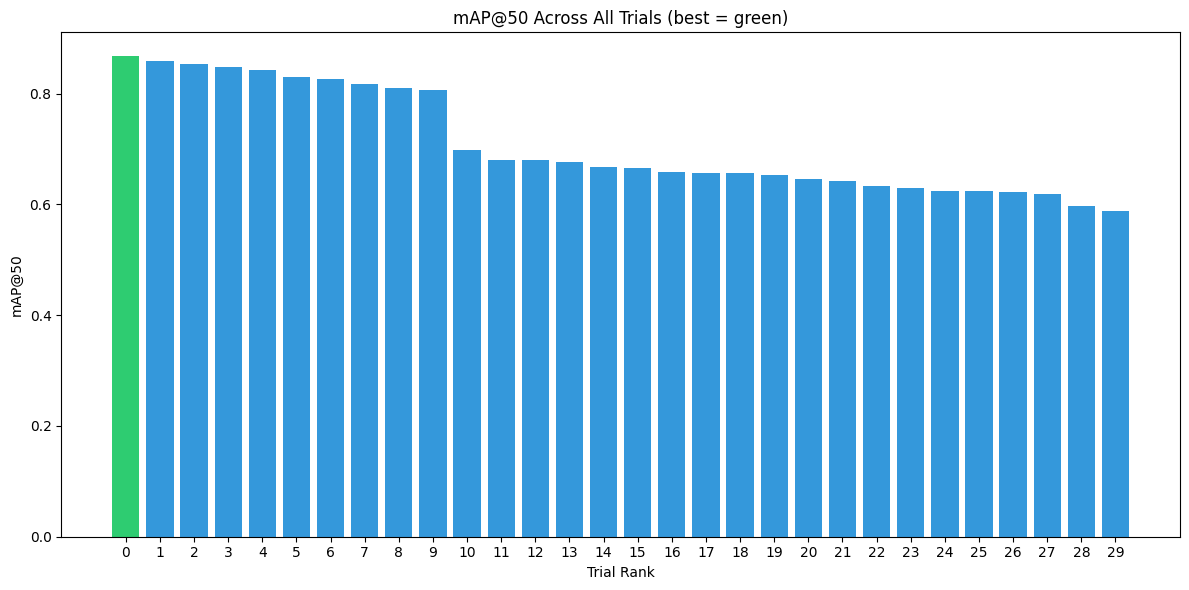

In [9]:
import matplotlib.pyplot as plt

# --- Plot 1: mAP@50 for all trials (bar chart) ---
df = analysis.dataframe(metric="metrics/mAP50(B)", mode="max")
df_sorted = df.sort_values("metrics/mAP50(B)", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#2ecc71" if i == 0 else "#3498db" for i in range(len(df_sorted))]
ax.bar(range(len(df_sorted)), df_sorted["metrics/mAP50(B)"], color=colors)
ax.set_xlabel("Trial Rank")
ax.set_ylabel("mAP@50")
ax.set_title("mAP@50 Across All Trials (best = green)")
ax.set_xticks(range(len(df_sorted)))
plt.tight_layout()
plt.show()

In [ ]:
# Get the best trial's full training history
best_trial = analysis.get_best_trial(metric="metrics/mAP50(B)", mode="max")
best_df = analysis.trial_dataframes[best_trial.local_path]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Best Trial Training Curves (trial: {best_trial.trial_id})", fontsize=14)

# mAP@50
axes[0, 0].plot(best_df["training_iteration"], best_df["metrics/mAP50(B)"], "b-")
axes[0, 0].set_title("mAP@50")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].grid(True, alpha=0.3)

# mAP@50:95
axes[0, 1].plot(best_df["training_iteration"], best_df["metrics/mAP50-95(B)"], "g-")
axes[0, 1].set_title("mAP@50:95")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].grid(True, alpha=0.3)

# Precision & Recall
axes[1, 0].plot(best_df["training_iteration"], best_df["metrics/precision(B)"], "r-", label="Precision")
axes[1, 0].plot(best_df["training_iteration"], best_df["metrics/recall(B)"], "b-", label="Recall")
axes[1, 0].set_title("Precision & Recall")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Classification Loss
axes[1, 1].plot(best_df["training_iteration"], best_df["val/cls_loss"], "m-")
axes[1, 1].set_title("Validation Cls Loss")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

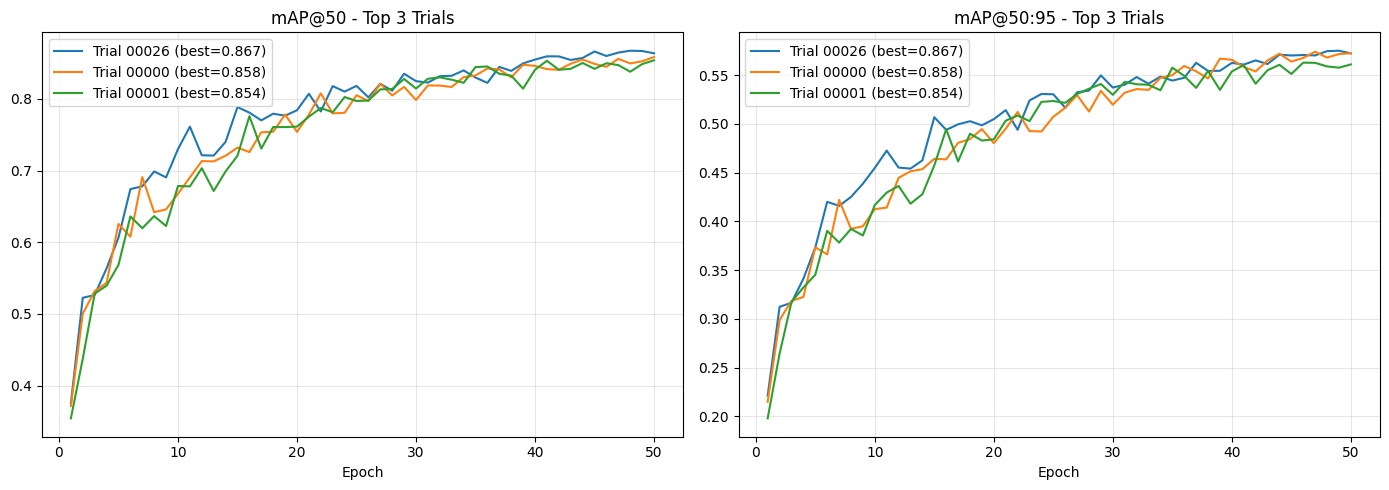

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get all trials sorted by mAP@50
all_trials = analysis.trial_dataframes  # dict: trial_dir -> DataFrame

# Get top 3 trial logdirs
df_all = analysis.dataframe(metric="metrics/mAP50(B)", mode="max")
top3_logdirs = df_all.sort_values("metrics/mAP50(B)", ascending=False).head(3)["logdir"].values

for logdir in top3_logdirs:
    trial_df = all_trials[logdir]
    trial_id = logdir.split("_")[-1]  # e.g. "00005"
    best_map = trial_df["metrics/mAP50(B)"].max()
    label = f"Trial {trial_id} (best={best_map:.3f})"

    axes[0].plot(trial_df["training_iteration"], trial_df["metrics/mAP50(B)"], label=label)
    axes[1].plot(trial_df["training_iteration"], trial_df["metrics/mAP50-95(B)"], label=label)

axes[0].set_title("mAP@50 - Top 3 Trials")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title("mAP@50:95 - Top 3 Trials")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

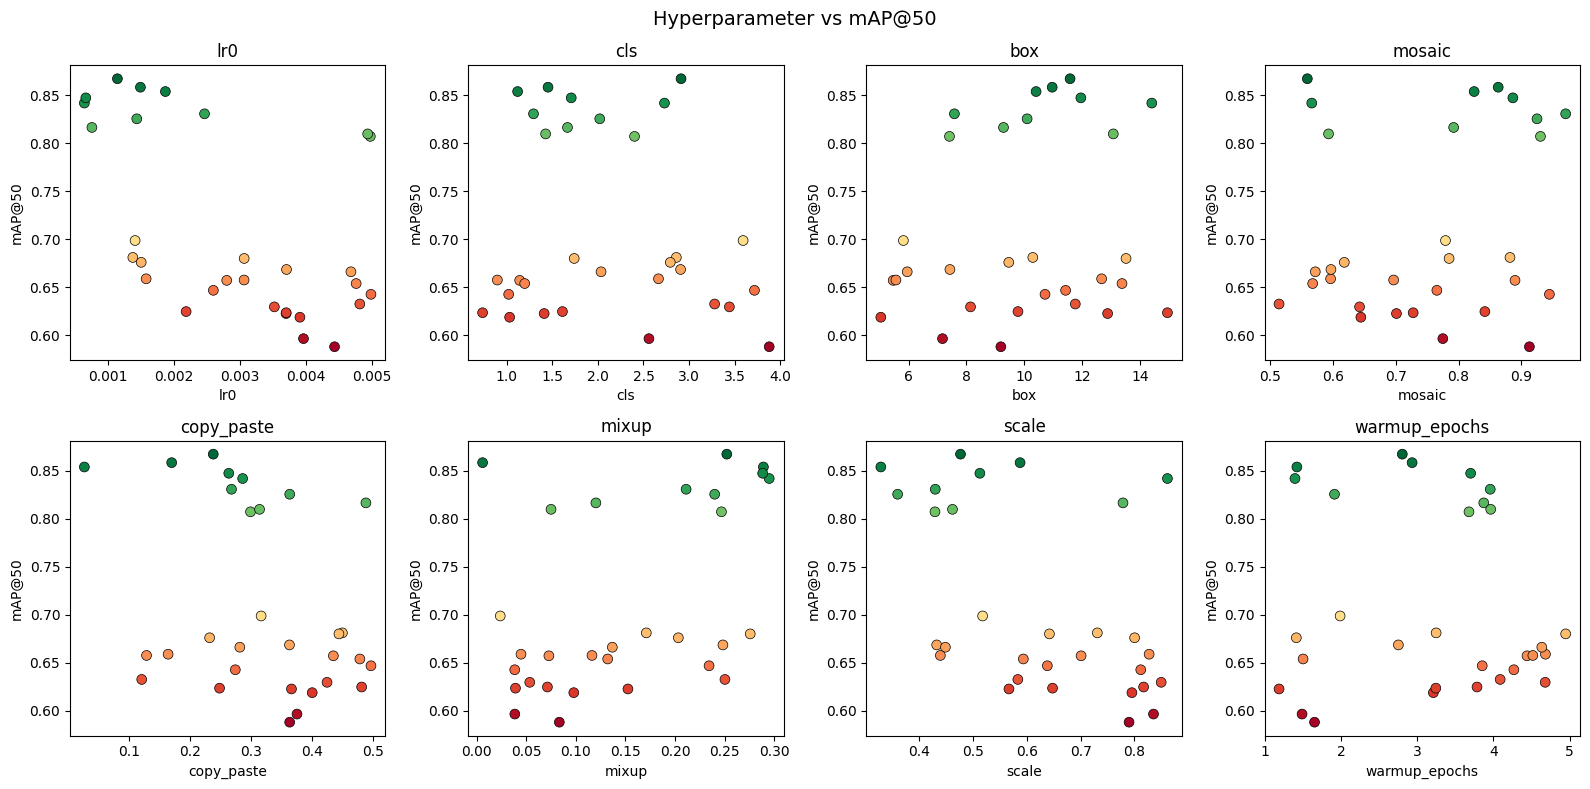

In [15]:
df = analysis.dataframe(metric="metrics/mAP50(B)", mode="max")

hp_keys = ["config/lr0", "config/cls", "config/box", "config/mosaic",
           "config/copy_paste", "config/mixup", "config/scale", "config/warmup_epochs"]
available_hps = [k for k in hp_keys if k in df.columns]

n = len(available_hps)
cols = min(4, n)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten() if n > 1 else [axes]

for i, hp in enumerate(available_hps):
    ax = axes[i]
    scatter = ax.scatter(df[hp], df["metrics/mAP50(B)"],
                         c=df["metrics/mAP50(B)"], cmap="RdYlGn",
                         s=50, edgecolors="black", linewidth=0.5)
    ax.set_xlabel(hp.replace("config/", ""))
    ax.set_ylabel("mAP@50")
    ax.set_title(hp.replace("config/", ""))

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Hyperparameter vs mAP@50", fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
df = analysis.dataframe(metric="metrics/mAP50(B)", mode="max")
print(f"Trials completed: {len(df)}")
print(f"Best mAP@50:  {df['metrics/mAP50(B)'].max():.4f}")
print(f"Worst mAP@50: {df['metrics/mAP50(B)'].min():.4f}")
print(f"Mean mAP@50:  {df['metrics/mAP50(B)'].mean():.4f}")
print(f"Std mAP@50:   {df['metrics/mAP50(B)'].std():.4f}")

Trials completed: 30
Best mAP@50:  0.8673
Worst mAP@50: 0.5878
Mean mAP@50:  0.7093
Std mAP@50:   0.0947


### Train YOLO26s

In [29]:
from ultralytics import YOLO

# Get the best config from your analysis
best_config = analysis.get_best_config(metric="metrics/mAP50(B)", mode="max")
print("Training with:", best_config)

model = YOLO("yolo26s.pt")
results = model.train(
    data="imbalanced-2/data.yaml",
    epochs=150, batch=16, imgsz=640, patience=20,
    optimizer="AdamW",

    # KEEP original loss/LR settings (these protected Bus)
    lr0=1e-3, lrf=0.01, weight_decay=5e-4, warmup_epochs=3.0,
    cls=1.5, box=7.5,

    # TRY tuned augmentation values (these helped SUV/Van/Truck)
    mosaic=best_config["mosaic"],
    copy_paste=best_config["copy_paste"],
    mixup=best_config["mixup"],
    scale=best_config["scale"],
    hsv_s=best_config["hsv_s"],
    hsv_v=best_config["hsv_v"],
    fliplr=best_config["fliplr"],
    close_mosaic=10,

    project="vehicle_detection",
    name="yolo26s_blended",
    plots=True, save=True, val=True,
)

Training with: {'lr0': 0.0011389183673899466, 'lrf': 0.023247351149902687, 'warmup_epochs': 2.803672987307901, 'weight_decay': 0.0005581167716748099, 'cls': 2.91253041577823, 'box': 11.579541160731747, 'mosaic': 0.5596187791163019, 'copy_paste': 0.2377317737132808, 'mixup': 0.2521068601707753, 'scale': 0.4763288673980503, 'hsv_s': 0.7313057550415705, 'hsv_v': 0.2916790520271597, 'fliplr': 0.4633864616072611, 'data': 'C:\\Users\\user\\Documents\\Vehicle-Detection-at-R-R-\\notebooks\\imbalanced-2\\data.yaml'}
Ultralytics 8.4.24  Python-3.11.9 torch-2.2.2+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.5, compile=False, conf=None, copy_paste=0.2377317737132808, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=imbalanced-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, drop

### Evaluate Fine-tuned Model

Before benchmarking the model, we need to load the best saved checkpoint. To ensure it fits on the GPU, we first need to free up GPU memory. This involves deleting any remaining references to previously used objects, triggering Python’s garbage collector, and clearing the CUDA memory cache.

In [5]:
import gc
import torch
import weakref

def cleanup_gpu_memory(obj=None, verbose: bool = False):

    if not torch.cuda.is_available():
        if verbose:
            print("[INFO] CUDA is not available. No GPU cleanup needed.")
        return

    def get_memory_stats():
        allocated = torch.cuda.memory_allocated()
        reserved = torch.cuda.memory_reserved()
        return allocated, reserved

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[Before] Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

    # Ensure we drop all strong references
    if obj is not None:
        ref = weakref.ref(obj)
        del obj
        if ref() is not None and verbose:
            print("[WARNING] Object not fully garbage collected yet.")

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[After]  Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

In [6]:
cleanup_gpu_memory(model, verbose=True)

[Before] Allocated: 489.11 MB | Reserved: 1756.00 MB
[WARNING] Object not fully garbage collected yet.
[After]  Allocated: 489.11 MB | Reserved: 1756.00 MB


In [11]:
from ultralytics import YOLO

model = YOLO("runs/detect/vehicle_detection/yolo26m/weights/best.pt")
metrics = model.val(data="7-classes-vehicle-1\data.yaml", split="test")

print(f"\nOverall mAP@50: {metrics.box.map50:.4f}")
print(f"Overall mAP@50:95: {metrics.box.map:.4f}")

# Per-class metrics
for i, name in enumerate(metrics.names.values()):
    print(f"  {name}: mAP@50={metrics.box.ap50[i]:.4f}, "
          f"P={metrics.box.p[i]:.4f}, R={metrics.box.r[i]:.4f}")

Ultralytics 8.4.34  Python-3.11.9 torch-2.2.2+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
YOLO26m summary (fused): 132 layers, 20,354,849 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 12.32.3 MB/s, size: 67.8 KB)
val: Scanning C:\Users\user\Documents\Vehicle-Detection-at-R-R-\7-classes-vehicle-1\test\labels... 728 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 728/728 464.3it/s 1.6s0.1s
val: New cache created: C:\Users\user\Documents\Vehicle-Detection-at-R-R-\7-classes-vehicle-1\test\labels.cache
WARNING Box and segment counts should be equal, but got len(segments) = 30, len(boxes) = 4203. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 46/46 2.8it/s 16.5s0.3s
                   all        728       4203     

In [33]:
# If you still have both results, compare side by side
# Original manual model
model_orig = YOLO("../runs/detect/vehicle_detection/yolo26s_imbalanced/weights/best.pt")
metrics_orig = model_orig.val(data="imbalanced-2/data.yaml", split="test")

# Tuned model
model_tuned = YOLO("../runs/detect/vehicle_detection/yolo26s_blended2/weights/best.pt")
metrics_tuned = model_tuned.val(data="imbalanced-2/data.yaml", split="test")

print(f"{'Class':<12} {'Original mAP50':>15} {'Tuned mAP50':>15} {'Delta':>10}")
print("-" * 55)
for i, name in enumerate(metrics_orig.names.values()):
    orig = metrics_orig.box.ap50[i]
    tuned = metrics_tuned.box.ap50[i]
    delta = tuned - orig
    marker = "+" if delta > 0 else ""
    print(f"{name:<12} {orig:>15.4f} {tuned:>15.4f} {marker}{delta:>9.4f}")
print("-" * 55)
print(f"{'Overall':<12} {metrics_orig.box.map50:>15.4f} {metrics_tuned.box.map50:>15.4f}")

Ultralytics 8.4.24  Python-3.11.9 torch-2.2.2+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
YOLO26s summary (fused): 122 layers, 9,467,889 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 130.312.5 MB/s, size: 65.4 KB)
val: Scanning C:\Users\user\Documents\Vehicle-Detection-at-R-R-\notebooks\imbalanced-2\test\labels.cache... 726 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 726/726  0.0s
WARNING Box and segment counts should be equal, but got len(segments) = 12, len(boxes) = 4140. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 46/46 4.3it/s 10.6s0.1s
                   all        726       4140        0.8      0.801      0.868      0.581
                   Bus          9          9      0.719      0.889      0.8

### Export for deployment (TensorRT)

In [4]:
from ultralytics import YOLO

model = YOLO("../runs/detect/vehicle_detection/yolo26s_imbalanced/weights/best.pt")
model.export(format="engine", half=True, imgsz=640)

WARNING TensorRT requires GPU export, automatically assigning device=0
Ultralytics 8.4.24  Python-3.11.9 torch-2.2.2+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
YOLO26s summary (fused): 122 layers, 9,467,889 parameters, 0 gradients, 20.5 GFLOPs

PyTorch: starting from '..\runs\detect\vehicle_detection\yolo26s_imbalanced\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (19.4 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB 1.3 MB/s eta 0:00:13
   ---------------------------------------- 0.1/16.4 MB 1.3 MB/s eta 0:00:13
   ---------------------------------------- 0.2/16.4 MB 1.5 MB/s eta 0:00:11
    --------------------------------------- 0.3/16.4 MB 1.9 MB/s eta 0:00:09
   - -------------------------------------- 0.5/16.4 MB 2.8 

Exporting aten::index operator of advanced indexing in opset 17 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.


ONNX: slimming with onnxslim 0.1.90...
ONNX: export success  41.0s, saved as '..\runs\detect\vehicle_detection\yolo26s_imbalanced\weights\best.onnx' (36.4 MB)

TensorRT: starting export with TensorRT 10.16.0.72...
TensorRT: input "images" with shape(1, 3, 640, 640) DataType.FLOAT
TensorRT: output "output0" with shape(1, 300, 6) DataType.FLOAT
TensorRT: building FP16 engine as ..\runs\detect\vehicle_detection\yolo26s_imbalanced\weights\best.engine
TensorRT: export success  265.4s, saved as '..\runs\detect\vehicle_detection\yolo26s_imbalanced\weights\best.engine' (21.4 MB)

Export complete (265.9s)
Results saved to C:\Users\user\Documents\Vehicle-Detection-at-R-R-\runs\detect\vehicle_detection\yolo26s_imbalanced\weights
Predict:         yolo predict task=detect model=..\runs\detect\vehicle_detection\yolo26s_imbalanced\weights\best.engine imgsz=640 half
Validate:        yolo val task=detect model=..\runs\detect\vehicle_detection\yolo26s_imbalanced\weights\best.engine imgsz=640 data=imbala

'..\\runs\\detect\\vehicle_detection\\yolo26s_imbalanced\\weights\\best.engine'